Device: cpu


100%|██████████| 170M/170M [00:03<00:00, 48.0MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train: 50000, Test: 10000

=== CNN Architecture ===
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)
Total params: 60362

=== Training for 5 epochs ===


Epoch 1/5:   0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/5] | Loss: 1.5456 | Val Acc: 54.62%


Epoch [2/5] | Loss: 1.2076 | Val Acc: 60.30%


Epoch [3/5] | Loss: 1.0788 | Val Acc: 62.66%


Epoch [4/5] | Loss: 0.9952 | Val Acc: 63.90%


Epoch [5/5] | Loss: 0.9365 | Val Acc: 66.81%

=== FINAL RESULTS ===
Final Val Accuracy: 66.81%
Best Val Accuracy: 66.81%
Loss progression: ['1.5456', '1.2076', '1.0788', '0.9952', '0.9365']


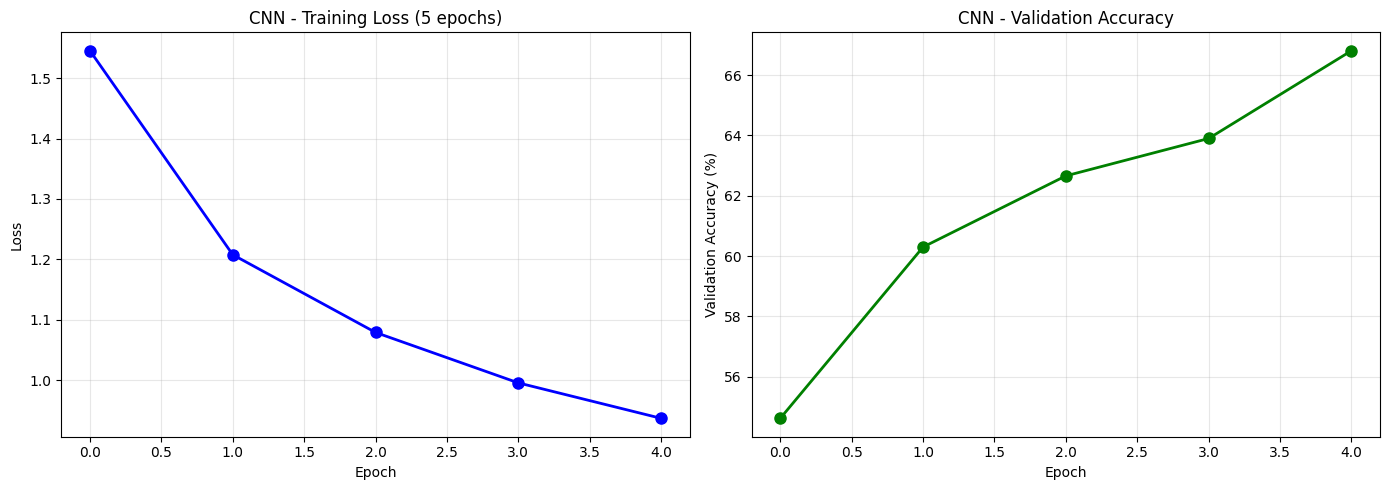


✓ Saved to 'cnn_first_results.png'


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ============================================
# LOAD DATA
# ============================================
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

# ============================================
# BUILD CNN (Conv→ReLU→Pool→Conv→ReLU→Pool→FC)
# ============================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First block: Conv→ReLU→Pool
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second block: Conv→ReLU→Pool
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        # After 2 pools (2x2 each): 32x32 → 16x16 → 8x8
        # 64 filters × 8 × 8 = 4096
        self.fc = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        # First block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Second block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Flatten and fully connected
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = SimpleCNN().to(device)
print("\n=== CNN Architecture ===")
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

# ============================================
# TRAINING
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_accs = []

num_epochs = 5
print(f"\n=== Training for {num_epochs} epochs ===")

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validate
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

# ============================================
# RESULTS & VISUALIZATION
# ============================================
print(f"\n=== FINAL RESULTS ===")
print(f"Final Val Accuracy: {val_accs[-1]:.2f}%")
print(f"Best Val Accuracy: {max(val_accs):.2f}%")
print(f"Loss progression: {[f'{l:.4f}' for l in train_losses]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CNN - Training Loss (5 epochs)')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(val_accs, marker='o', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('CNN - Validation Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_first_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved to 'cnn_first_results.png'")